# Lista 6

In [3]:
import torch
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

## Zadanie 0

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Dla maski używamy PILToTensor() zamiast ToTensor()
# PILToTensor() nie normalizuje wartości, zachowuje oryginalne 1, 2, 3
target_transform = transforms.Compose([
    transforms.PILToTensor()
])

dataset = datasets.OxfordIIITPet(
    root='./data',
    split='trainval',  
    target_types='segmentation',
    download=True,
    transform=transform,
    target_transform=target_transform
)

# Sprawdź wartości w masce
sample_img, sample_mask = dataset[0]


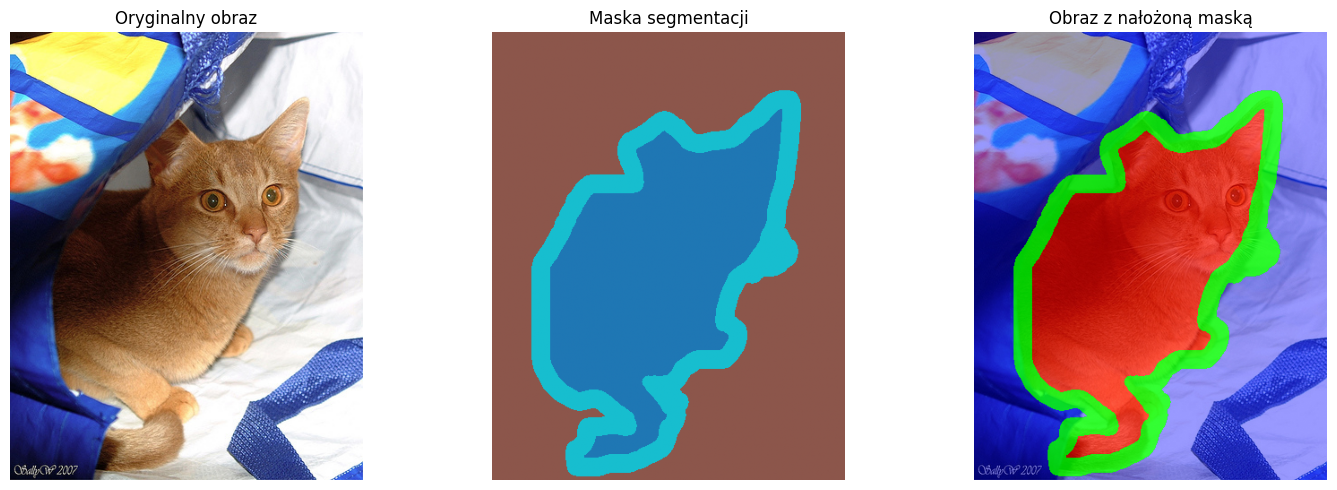

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Oryginalny obraz
img_display = sample_img.permute(1, 2, 0).numpy()
axes[0].imshow(img_display)
axes[0].set_title('Oryginalny obraz')
axes[0].axis('off')

# Maska segmentacji
mask_display = sample_mask.squeeze().numpy()
axes[1].imshow(mask_display, cmap='tab10')
axes[1].set_title('Maska segmentacji')
axes[1].axis('off')

# Obraz z nałożoną maską
axes[2].imshow(img_display)
mask_colored = np.zeros((*mask_display.shape, 4))
mask_colored[mask_display == 1] = [1, 0, 0, 0.6]  
mask_colored[mask_display == 2] = [0, 0, 1, 0.4]  
mask_colored[mask_display == 3] = [0, 1, 0, 0.8]  
axes[2].imshow(mask_colored)
axes[2].set_title('Obraz z nałożoną maską')
axes[2].axis('off')

plt.tight_layout()
plt.show()


